In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PowerTransformer
import lightgbm as lgb
import shap

In [12]:
df = pd.read_csv('/content/drive/MyDrive/colab/mlpr/dataset.csv')

In [13]:
display(df.columns)

Index(['timestamp', 'pm25_ugm3', 'pm10_ugm3', 'no_ugm3', 'no2_ugm3', 'nox_ppb',
       'nh3_ugm3', 'so2_ugm3', 'co_mgm3', 'ozone_ugm3', 'at_c', 'rh_pct',
       'ws_ms', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_wm2', 'state', 'city',
       'station', 'station_id', 'latitude', 'longitude', 'era5_sw_down_wm2',
       'era5_dewpoint_k', 'era5_pressure_pa', 'era5_temp_k',
       'era5_cloud_cover', 'era5_precip_m', 'era5_u10_ms', 'era5_v10_ms',
       'era5_temp_c', 'era5_dewpoint_c', 'era5_pressure_hpa', 'era5_precip_mm',
       'era5_wind_speed_ms', 'era5_wind_dir_deg', 'era5_vpd_kpa',
       'era5_rh_pct', 'solar_altitude_deg', 'solar_zenith_deg', 'cos_zenith'],
      dtype='object')

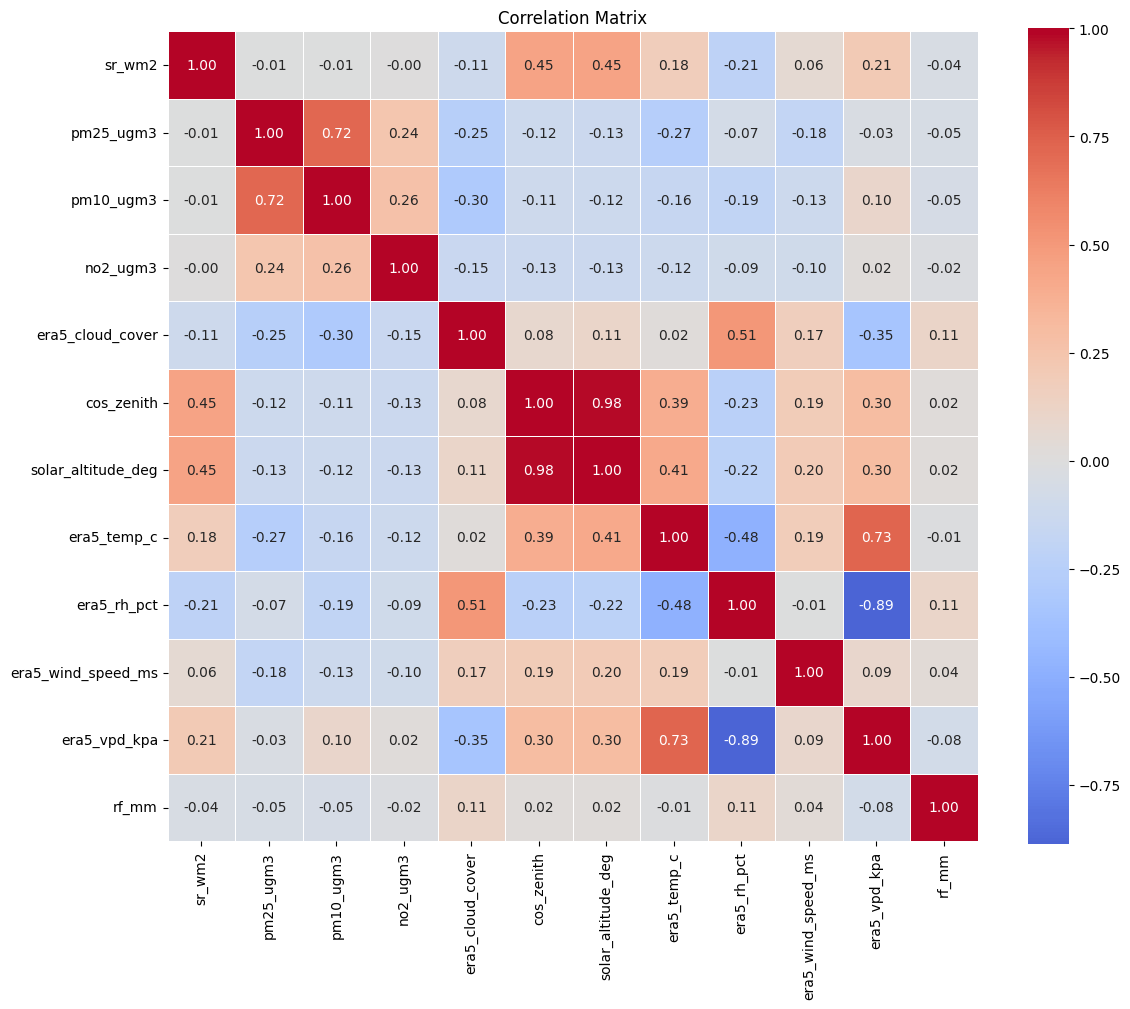

In [15]:
cols = [
    'sr_wm2',
    'pm25_ugm3',
    'pm10_ugm3',
    'no2_ugm3',
    'era5_cloud_cover',
    'cos_zenith',
    'solar_altitude_deg',
    'era5_temp_c',
    'era5_rh_pct',
    'era5_wind_speed_ms',
    'era5_vpd_kpa',
    'rf_mm',
]

existing_cols = [c for c in cols if c in df.columns]

corr = df[existing_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
display(df.head())

,timestamp,pm25_ugm3,pm10_ugm3,no_ugm3,no2_ugm3,nox_ppb,nh3_ugm3,so2_ugm3,co_mgm3,ozone_ugm3,...,era5_dewpoint_c,era5_pressure_hpa,era5_precip_mm,era5_wind_speed_ms,era5_wind_dir_deg,era5_vpd_kpa,era5_rh_pct,solar_altitude_deg,solar_zenith_deg,cos_zenith
0,2023-01-01 07:00:00,19.0850,38.7950,14.3825,4.9475,14.3225,10.1550,3.4800,0.762500,4.7650,...,18.639252,968.30910,0.0,1.847223,286.17410,0.379077,85.001900,4.667164,85.332836,0.081367
1,2023-01-01 08:00:00,19.1350,38.8975,9.1650,13.3700,14.5650,10.9125,3.4375,1.042500,22.4000,...,19.144073,969.10800,0.0,1.057138,281.99472,0.583014,79.179830,17.531929,72.468071,0.301237
2,2023-01-01 09:00:00,19.1250,38.8800,3.1075,14.1600,10.0575,8.3875,4.1700,0.962500,64.2825,...,16.855865,969.54360,0.0,0.296382,246.03333,0.990462,65.970090,29.755576,60.244424,0.496301
3,2023-01-01 10:00:00,19.1500,38.9275,1.5975,7.2875,5.1775,5.2475,3.9150,0.683333,83.7625,...,16.033600,969.54047,0.0,0.617172,98.50652,1.652197,52.446415,40.674314,49.325686,0.651758
4,2023-01-01 11:00:00,19.1675,38.9600,1.4775,4.5375,3.6150,3.9950,4.3350,0.665051,89.8950,...,15.203644,968.76470,0.0,1.255265,78.64212,2.185008,44.158020,49.187884,40.812116,0.756857


In [ ]:
target_encoders = {}

for col in ['station_id', 'station', 'state', 'city']:
    if col in df.columns:
        target_encoders[col] = df.groupby(col)['sr_wm2'].mean().to_dict()

# Apply encoding to entire dataset
global_mean = df['sr_wm2'].mean()
for col in ['station_id', 'station', 'state', 'city']:
    if col in df.columns:
        df[f'{col}_encoded'] = df[col].map(target_encoders[col])
        df[f'{col}_encoded'] = df[f'{col}_encoded'].fillna(global_mean)


float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2549291 entries, 0 to 2549290
Data columns (total 46 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   pm25_ugm3           float32       
 2   pm10_ugm3           float32       
 3   no_ugm3             float32       
 4   no2_ugm3            float32       
 5   nox_ppb             float32       
 6   nh3_ugm3            float32       
 7   so2_ugm3            float32       
 8   co_mgm3             float32       
 9   ozone_ugm3          float32       
 10  at_c                float32       
 11  rh_pct              float32       
 12  ws_ms               float32       
 13  wd_deg              float32       
 14  rf_mm               float32       
 15  tot_rf_mm           float32       
 16  sr_wm2              float32       
 17  state               object        
 18  city                object        
 19  station             object        
 20  st

In [ ]:
# Make sure rows are in chronological order
df = df.sort_values("timestamp").reset_index(drop=True)

# Feature engineering
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

# Drop obvious redundancies
cols_to_drop = [
    'timestamp',
    'at_c', 'rh_pct', 'ws_ms', 'wd_deg', 'rf_mm', 'tot_rf_mm',
    'station_id', 'station', 'state', 'city',
    'era5_temp_k', 'era5_dewpoint_k', 'era5_pressure_pa',
    'era5_u10_ms', 'era5_v10_ms',
    'era5_precip_m',
    'solar_altitude_deg',
    'era5_sw_down_wm2',
]

df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
# Cyclical Time Encoding 
df['hour_sin'] = np.sin(df['hour'] * (2. * np.pi / 24)).astype('float32')
df['hour_cos'] = np.cos(df['hour'] * (2. * np.pi / 24)).astype('float32')
df['month_sin'] = np.sin((df['month'] - 1) * (2. * np.pi / 12)).astype('float32')
df['month_cos'] = np.cos((df['month'] - 1) * (2. * np.pi / 12)).astype('float32')

# Drop the raw hour and month columns as they are no longer needed
df = df.drop(columns=['hour', 'month'])
df = df.sort_values(by=['station_id_encoded', 'year', 'hour_sin'])
df = df.dropna()

In [ ]:
# Define the columns that should NEVER be lagged
columns_to_ignore = [
    'timestamp', 'state', 'city', 'station', 'station_id', 
    'station_id_encoded', 'latitude', 'longitude', 
    'solar_altitude_deg', 'solar_zenith_deg', 'cos_zenith', 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'year'
]

# List of lag columns
columns_to_lag = [col for col in df.columns if col not in columns_to_ignore]

print(f"Adding lags for {len(columns_to_lag)} dynamic features...")
df = df.sort_values(by=['station_id_encoded', 'year', 'hour_sin'])

for col in columns_to_lag:
    # 1-hour lag
    df[f'{col}_lag1'] = df.groupby('station_id_encoded')[col].shift(1).astype('float32')
    
    # 24-hour lag
    df[f'{col}_lag24'] = df.groupby('station_id_encoded')[col].shift(24).astype('float32')

print(f"Original row count: {len(df)}")
df = df.dropna()
print(f"Row count after dropping initial NaNs: {len(df)}")

Adding lags for 23 dynamic features...
Original row count: 2549291
Row count after dropping initial NaNs: 2543891


In [ ]:
# Normalize the Target Variable (Yeo-Johnson Power Transform)
pt = PowerTransformer(method='yeo-johnson')
df['sr_wm2_scaled'] = pt.fit_transform(df[['sr_wm2']]).astype('float32')

train_df = df[df['year'] < 2025]
test_df = df[df['year'] >= 2025]

features = [col for col in df.columns if col not in ['sr_wm2', 'sr_wm2_scaled', 'year']]

X_train = train_df[features]
y_train = train_df['sr_wm2_scaled']

X_test = test_df[features]
y_test = test_df['sr_wm2_scaled']

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Training rows: 1694822 | Testing rows: 849069


In [ ]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define Model Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'feature_fraction': 0.8,
    'n_jobs': -1
}

# Train the Model
print("Starting training...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Predict and Inverse Transform
preds_scaled = model.predict(X_test, num_iteration=model.best_iteration)

preds_original_scale = pt.inverse_transform(preds_scaled.reshape(-1, 1))
y_test_original_scale = pt.inverse_transform(y_test.values.reshape(-1, 1))

# Evaluate
mae = mean_absolute_error(y_test_original_scale, preds_original_scale)
rmse = np.sqrt(mean_squared_error(y_test_original_scale, preds_original_scale))
r2 = r2_score(y_test_original_scale, preds_original_scale)

print(f"\n--- Model Performance ---")
print(f"MAE:  {mae:.2f} W/m²")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"R²:   {r2:.4f}")

Starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.369587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17033
[LightGBM] [Info] Number of data points in the train set: 1694822, number of used features: 77
[LightGBM] [Info] Start training from score 0.034153
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[410]	training's rmse: 0.330071	valid_1's rmse: 0.359243

--- Model Performance ---
MAE:  44.35 W/m²
RMSE: 90.62 W/m²
R²:   0.8194


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


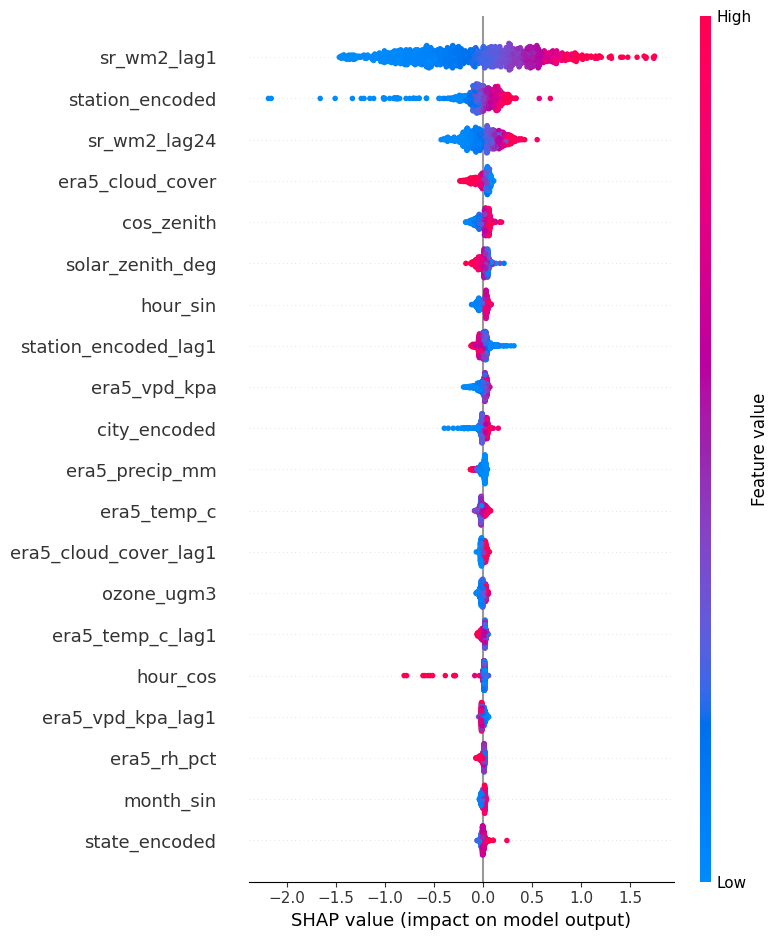

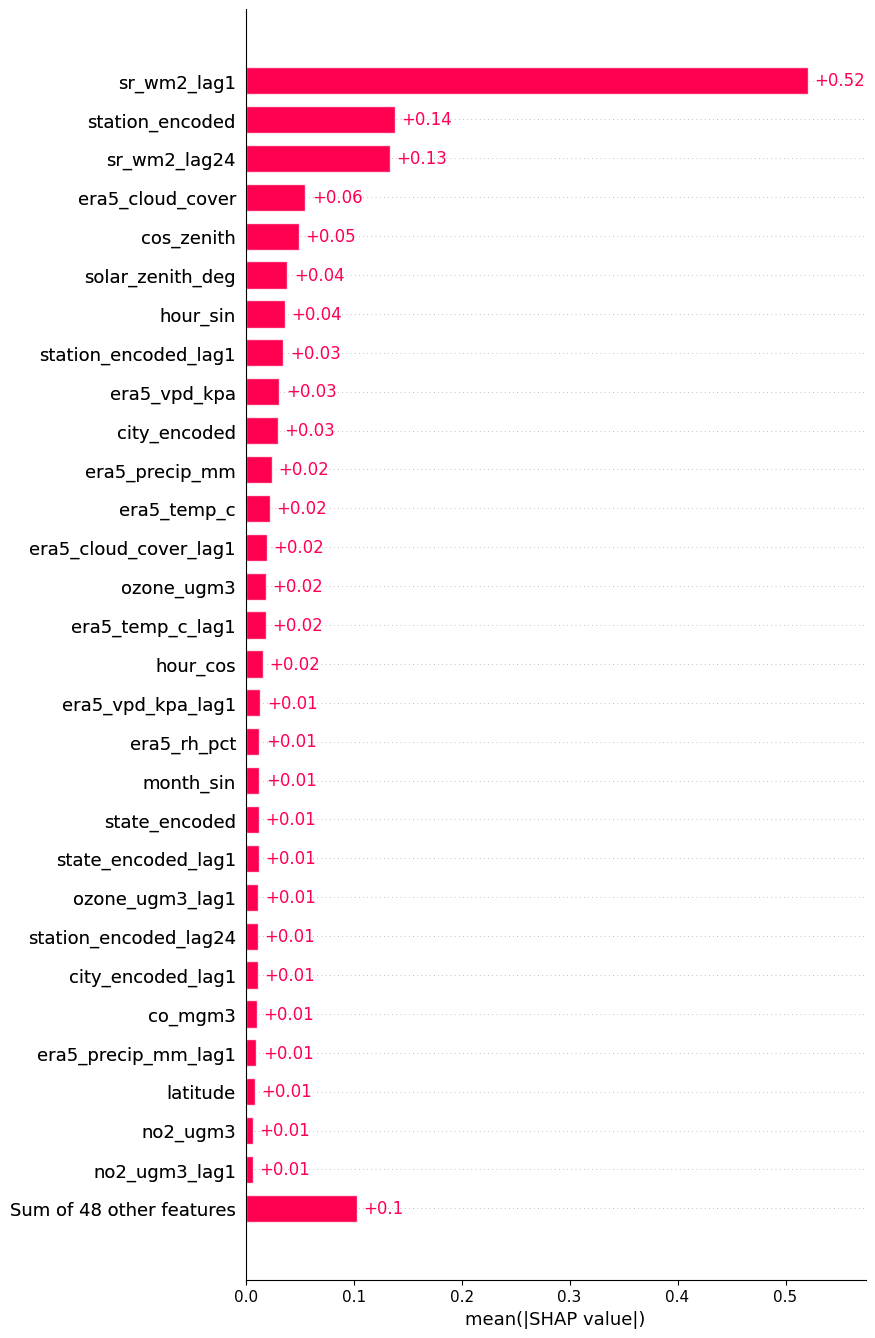

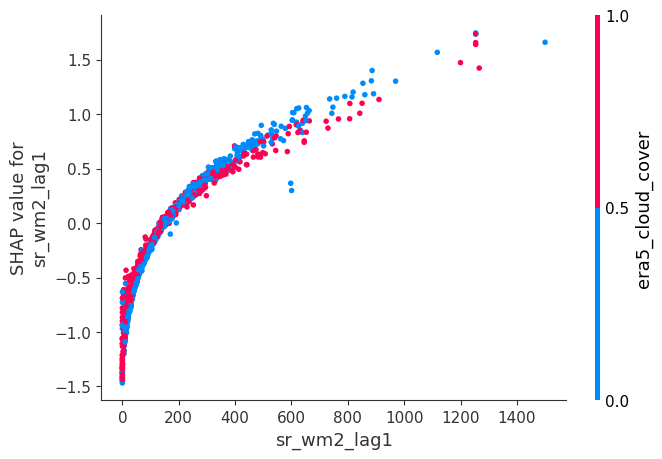

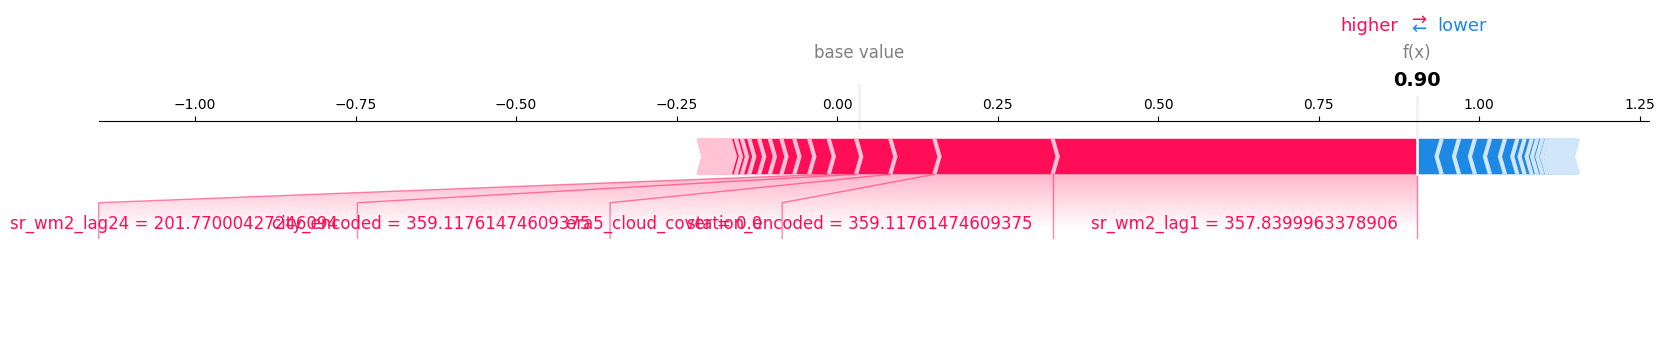

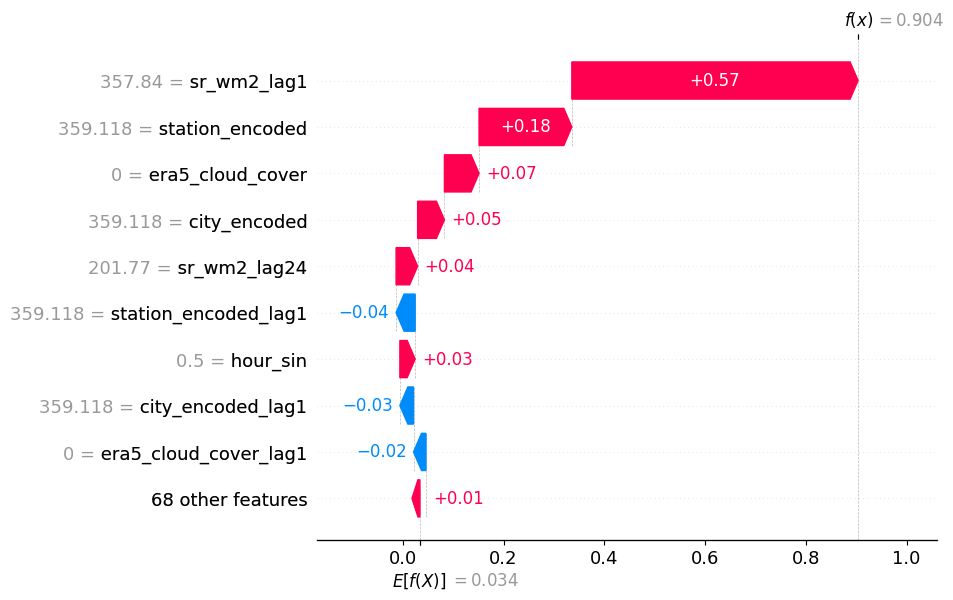

In [ ]:
shap.initjs()

# sample to keep plotting responsive
n_sample = min(1000, len(X_test))
X_sample = X_test.sample(n_sample, random_state=0)

explainer = shap.Explainer(model)
shap_values = explainer(X_sample)

# Beeswarm summary
shap.summary_plot(shap_values, X_sample, show=True)

# Bar plot (mean absolute importance)
shap.plots.bar(shap_values, max_display=30)

# Dependence plot for the top feature
import numpy as np
feature_importance = np.abs(shap_values.values).mean(0)
top_idx = int(np.argmax(feature_importance))
top_feat = X_sample.columns[top_idx]
shap.dependence_plot(top_feat, shap_values.values, X_sample, show=True)

# 4) Force and waterfall plots for a single instance (first sample)
shap.plots.force(shap_values[0], matplotlib=True)
shap.plots.waterfall(shap_values[0])